<a href="https://colab.research.google.com/github/dilp90/Artificial_Intelligence_FIME/blob/main/Ejercicios/PpIA_Ejercicio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio 2 .- Uso de Pandas, Matplotlib, Numpy**



Instrucciones: Para estos ejercicios utilizaremos el conjunto de datos Pingüinos de Palmer (Palmer Penguins).

# **Ejercicio 2.1.- Análisis Exploratorio con Pandas**

Cargar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Carga el dataset de Pingüinos de Palmer.

In [4]:
# URL del dataset de pingüinos de Palmer
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

# Cargar los datos
df = pd.read_csv(url)

# Mostrar los primeros registros para confirmar
print("¡Dataset cargado correctamente!")

¡Dataset cargado correctamente!


2. Manejo de Nulos: Identifica cuántas filas tienen valores NaN. Elimina aquellas filas donde falten datos críticos (como el peso o el tamaño del pico).

In [6]:
# Identificar la cantidad de valores NaN por columna
print("Valores NaN por columna antes de la eliminación:")
print(df.isnull().sum())

Valores NaN por columna antes de la eliminación:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64


In [7]:
# Identificar las filas con valores NaN en las columnas críticas
critical_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
rows_with_nan_in_critical = df[df[critical_columns].isnull().any(axis=1)]
print(f"\nNúmero de filas con NaN en columnas críticas: {len(rows_with_nan_in_critical)}")


Número de filas con NaN en columnas críticas: 0


In [8]:
# Eliminar filas donde falten datos críticos
df_cleaned = df.dropna(subset=critical_columns)

In [10]:
# Mostrar la forma del DataFrame antes y después de la eliminación
print(f"\nForma del DataFrame antes de la eliminación: {df.shape}")
print(f"Forma del DataFrame después de la eliminación: {df_cleaned.shape}")


Forma del DataFrame antes de la eliminación: (342, 7)
Forma del DataFrame después de la eliminación: (342, 7)


In [11]:
# Actualizar el DataFrame original (opcional, pero buena práctica si el usuario espera continuar con el df limpio)
df = df_cleaned.copy()

3. Agrupación: Calcula la masa corporal (body_mass_g) promedio por cada especie y por isla.

In [12]:
# Calcula la masa corporal promedio por especie y por isla
average_body_mass = df.groupby(['species', 'island'])['body_mass_g'].mean().reset_index()

# Muestra los resultados
print("Masa corporal promedio por especie y por isla:")
display(average_body_mass)

Masa corporal promedio por especie y por isla:


,species,island,body_mass_g
0,Adelie,Biscoe,3709.659091
1,Adelie,Dream,3688.392857
2,Adelie,Torgersen,3706.372549
3,Chinstrap,Dream,3733.088235
4,Gentoo,Biscoe,5076.016260


4. Segmentación: Crea un subconjunto de datos que solo contenga a los pingüinos de la especie "Gentoo" que pesen más de 5000g.

In [13]:
# Subconjunto de datos para pingüinos 'Gentoo' que pesan más de 5000g
gentoo_heavy_penguins = df[(df['species'] == 'Gentoo') & (df['body_mass_g'] > 5000)]

# Muestra los primeros registros del subconjunto
print("Pingüinos 'Gentoo' con masa corporal mayor a 5000g:")
display(gentoo_heavy_penguins.head())

# Muestra la forma del nuevo subconjunto para confirmar la cantidad de registros
print(f"\nNúmero de pingüinos 'Gentoo' que pesan más de 5000g: {gentoo_heavy_penguins.shape[0]}")

Pingüinos 'Gentoo' con masa corporal mayor a 5000g:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,MALE
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,MALE
227,Gentoo,Biscoe,46.7,15.3,219.0,5200.0,MALE
229,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,MALE



Número de pingüinos 'Gentoo' que pesan más de 5000g: 61


# **Ejercicio 2.2.- Procesamiento de Señales con NumPy**



1. Extrae las columnas bill_length_mm (largo) y bill_depth_mm (alto) y conviértelas en una matriz de NumPy de $N \times 2$.

In [14]:
# Extraer las columnas 'bill_length_mm' y 'bill_depth_mm'
bill_dimensions_df = df[['bill_length_mm', 'bill_depth_mm']]

# Convertir el DataFrame a una matriz NumPy
bill_dimensions_np = bill_dimensions_df.values

print("Primeros 5 registros de la matriz NumPy:")
print(bill_dimensions_np[:5])
print(f"\nForma de la matriz NumPy: {bill_dimensions_np.shape}")

Primeros 5 registros de la matriz NumPy:
[[39.1 18.7]
 [39.5 17.4]
 [40.3 18. ]
 [36.7 19.3]
 [39.3 20.6]]

Forma de la matriz NumPy: (342, 2)


2. Cálculo de Proporción: Crea un nuevo array que sea el resultado de dividir el largo entre el alto para cada pingüino.

In [15]:
# Crear un nuevo array que sea el resultado de dividir el largo entre el alto
bill_proportion_np = bill_dimensions_np[:, 0] / bill_dimensions_np[:, 1]

print("Primeros 5 registros del array de proporciones:")
print(bill_proportion_np[:5])
print(f"\nForma del array de proporciones: {bill_proportion_np.shape}")

Primeros 5 registros del array de proporciones:
[2.09090909 2.27011494 2.23888889 1.9015544  1.90776699]

Forma del array de proporciones: (342,)


3. Detección de Outliers: Utiliza una función de NumPy para encontrar qué pingüinos tienen un largo de pico que esté a más de 2 desviaciones estándar de la media del grupo.

In [18]:
# Extraer la columna 'bill_length_mm' para el análisis y convertirla en un arreglo de Numpy
bill_length = df['bill_length_mm'].values

# Calcular la media y la desviación estándar del largo del pico
mean_bill_length = np.mean(bill_length)
std_bill_length = np.std(bill_length)

# Definir los límites para la detección de outliers (2 desviaciones estándar)
upper_bound = mean_bill_length + 2 * std_bill_length
lower_bound = mean_bill_length - 2 * std_bill_length

# Encontrar los pingüinos que son outliers
outlier_indices = np.where((bill_length > upper_bound) | (bill_length < lower_bound)) # Aquí el símbolo "|" significa "or"
outlier_penguins = df.iloc[outlier_indices]

print(f"Media del largo del pico: {mean_bill_length:.2f} mm")
print(f"Desviación estándar del largo del pico: {std_bill_length:.2f} mm")
print(f"Límite superior (media + 2*std): {upper_bound:.2f} mm")
print(f"Límite inferior (media - 2*std): {lower_bound:.2f} mm")

print(f"\nNúmero de pingüinos con largo de pico a más de 2 desviaciones estándar: {len(outlier_penguins)}")
print("\nPingüinos considerados outliers por el largo del pico:")
display(outlier_penguins)

Media del largo del pico: 43.92 mm
Desviación estándar del largo del pico: 5.45 mm
Límite superior (media + 2*std): 54.83 mm
Límite inferior (media - 2*std): 33.02 mm

Número de pingüinos con largo de pico a más de 2 desviaciones estándar: 6

Pingüinos considerados outliers por el largo del pico:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
142,Adelie,Dream,32.1,15.5,188.0,3050.0,FEMALE
169,Chinstrap,Dream,58.0,17.8,181.0,3700.0,FEMALE
215,Chinstrap,Dream,55.8,19.8,207.0,4000.0,MALE
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,MALE
321,Gentoo,Biscoe,55.9,17.0,228.0,5600.0,MALE
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,MALE


4. Slicing: Extrae solo los datos de los pingüinos que están en las posiciones pares del array original.

In [19]:
# Extraer solo los datos de los pingüinos que están en las posiciones pares
even_indexed_penguins = df.iloc[::2]

print("Primeros 5 registros de los pingüinos con índices pares:")
display(even_indexed_penguins.head())

print(f"\nNúmero de pingüinos con índices pares: {len(even_indexed_penguins)}")

Primeros 5 registros de los pingüinos con índices pares:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN



Número de pingüinos con índices pares: 171


# **Ejercicio 2.3.- Visualización Científica con Matplotlib**

1. Scatter Plot: Grafica flipper_length_mm (aletas) en el eje X y body_mass_g en el eje Y.

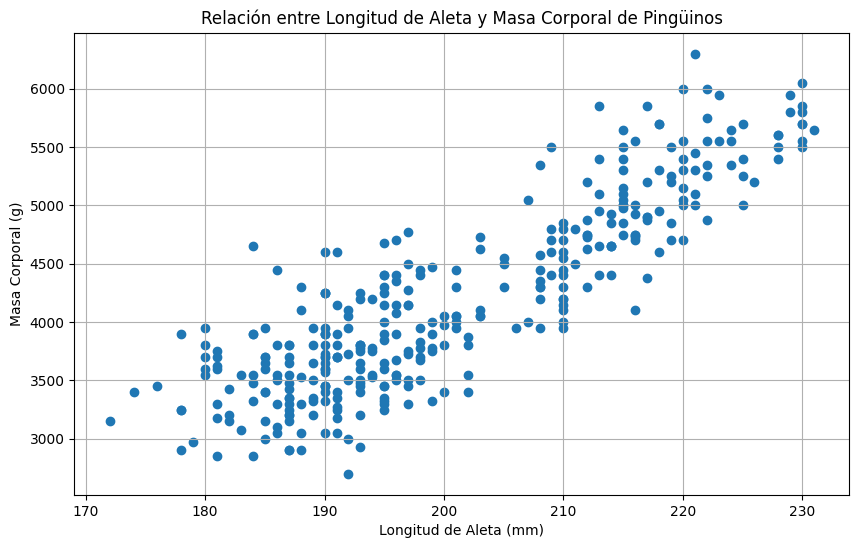

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['flipper_length_mm'], df['body_mass_g'])
plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.title('Relación entre Longitud de Aleta y Masa Corporal de Pingüinos')
plt.grid(True)
plt.show()

2. Codificación de Colores: Usa un color diferente para cada una de las tres especies (Adelie, Chinstrap, Gentoo). Esto ayudará a ver cómo se agrupan naturalmente.

/tmp/ipykernel_408/394117837.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(species_list))


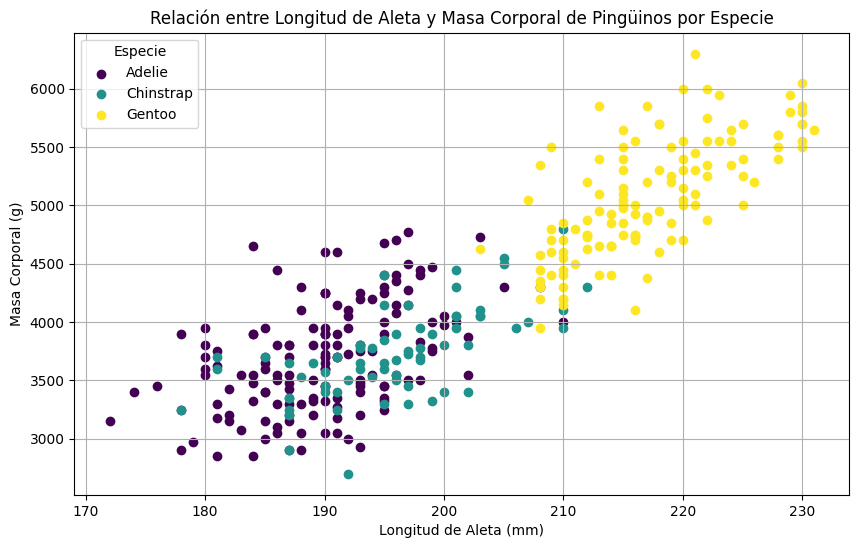

In [21]:
plt.figure(figsize=(10, 6))

# Obtener las especies únicas para asignar colores
species_list = df['species'].unique()
colors = plt.cm.get_cmap('viridis', len(species_list))

for i, species in enumerate(species_list):
    subset = df[df['species'] == species]
    plt.scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                color=colors(i), label=species)

plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.title('Relación entre Longitud de Aleta y Masa Corporal de Pingüinos por Especie')
plt.grid(True)
plt.legend(title='Especie')
plt.show()

3. Anotaciones: Añade una flecha o un texto en el gráfico señalando al pingüino más pesado del dataset.

/tmp/ipykernel_408/60901860.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(species_list))


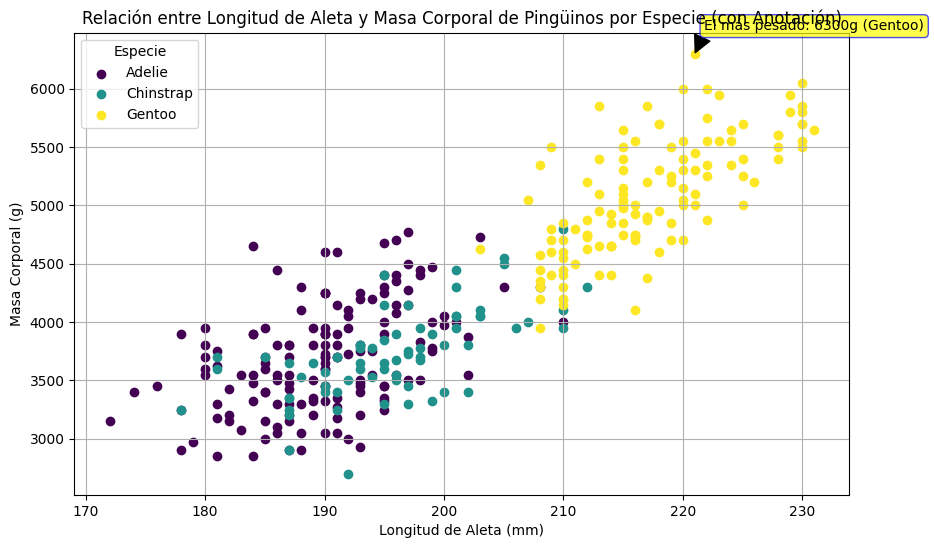

In [22]:
# Encontrar el pingüino más pesado
heaviest_penguin = df.loc[df['body_mass_g'].idxmax()]

# Obtener las coordenadas para la anotación
heaviest_x = heaviest_penguin['flipper_length_mm']
heaviest_y = heaviest_penguin['body_mass_g']
heaviest_species = heaviest_penguin['species']

plt.figure(figsize=(10, 6))

# Obtener las especies únicas para asignar colores (reutilizando la lógica anterior)
species_list = df['species'].unique()
colors = plt.cm.get_cmap('viridis', len(species_list))

for i, species in enumerate(species_list):
    subset = df[df['species'] == species]
    plt.scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                color=colors(i), label=species)

# Añadir la anotación para el pingüino más pesado
plt.annotate(f'El más pesado: {heaviest_y:.0f}g ({heaviest_species})',
             xy=(heaviest_x, heaviest_y),
             xytext=(heaviest_x + 10, heaviest_y + 200),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center',
             fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.7))

plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.title('Relación entre Longitud de Aleta y Masa Corporal de Pingüinos por Especie (con Anotación)')
plt.grid(True)
plt.legend(title='Especie')
plt.show()

4. Layout: Crea una figura con dos "subplots" (gráficos uno al lado del otro): uno con la masa corporal y otro con el tamaño de las aletas.

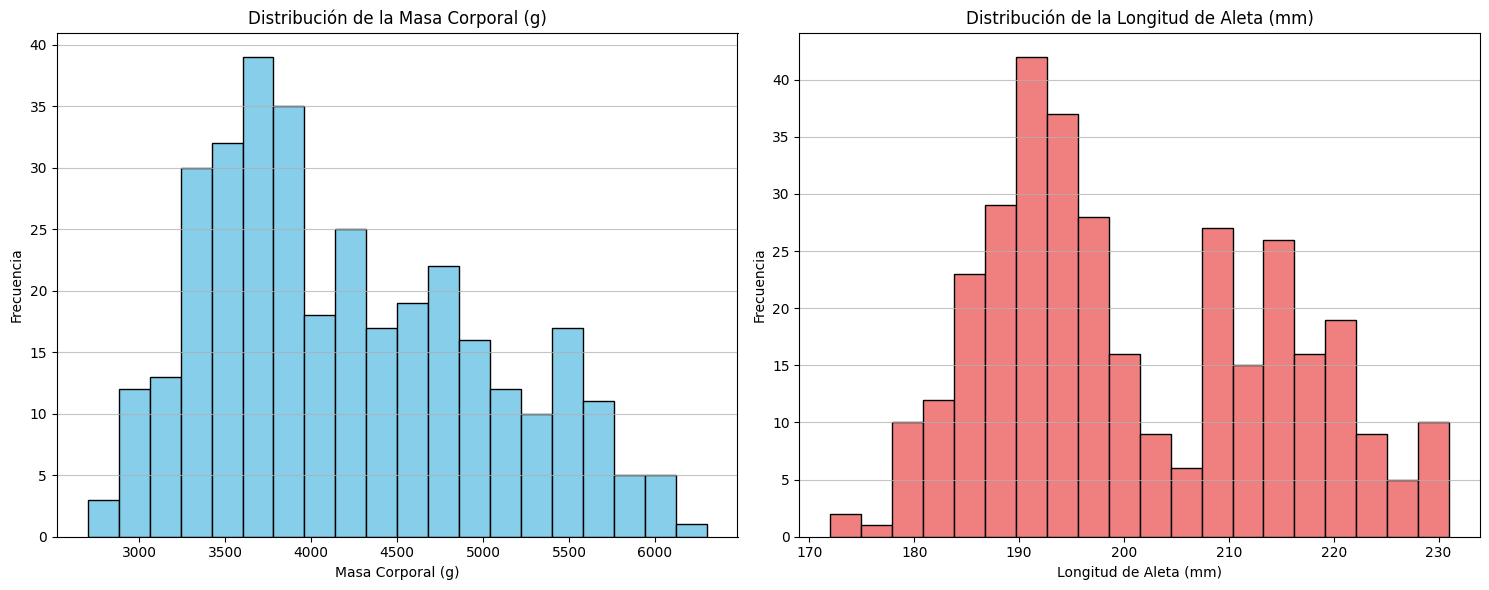

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Histograma de Masa Corporal
axes[0].hist(df['body_mass_g'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de la Masa Corporal (g)')
axes[0].set_xlabel('Masa Corporal (g)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.75)

# Subplot 2: Histograma de Longitud de Aleta
axes[1].hist(df['flipper_length_mm'].dropna(), bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribución de la Longitud de Aleta (mm)')
axes[1].set_xlabel('Longitud de Aleta (mm)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout() # Ajusta el diseño para evitar superposiciones
plt.show()